# Neural Networks

In [33]:

# %load_ext autoreload
# %reload_ext autoreload
# %autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parents[1]))  # workaround to resolve my helper module above

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pickle
import tensorflow as tf

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K 

from modules.plotting import *

DATA_PATH = "./data/"
MODELS_PATH = "./models/"
SUBMISSIONS_PATH = "./submissions/"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [109]:
def preprocessing_for_test_with_dropping_least_correlated(test: pl.DataFrame) -> pl.DataFrame:

    test_for_eng = test.with_columns(
        (pl.col("total_luminosity") - pl.col("min_luminosity")).alias("delta_luminosity")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("plate_thickness") * pl.col("plate_length")).alias("volume_proxy")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("volume_proxy") / pl.col("processing_time")).alias("processing_efficiency")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("defect_area") / pl.col("volume_proxy")).alias("defect_proportion")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("square_index") * pl.col("edge_index")).alias("geometry_score")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("temperature") / pl.col("cooling_rate")).alias("cooling_difficulty")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("brightness_index") * pl.col("volume_proxy")).alias("brightness_times_volume")
    )

    return test_for_eng.drop(
        "volume_proxy", 
        "plate_length", 
        "min_luminosity", 
        "defect_area", 
        "edge_index", 
        "processing_time", 
        "temperature",
        "cooling_difficulty",
        "plate_thickness"
    )

In [34]:
training_data = pl.read_csv(DATA_PATH + "one_hot_encoded.csv")
test_data = pl.read_csv(DATA_PATH + "test.csv")

In [35]:
X = training_data.drop("quality_score")
y = training_data["quality_score"]

In [110]:
X = preprocessing_for_test_with_dropping_least_correlated(X)
X

brightness_index,square_index,total_luminosity,cooling_rate,operator_id_1,operator_id_10,operator_id_11,operator_id_12,operator_id_13,operator_id_14,operator_id_15,operator_id_16,operator_id_17,operator_id_18,operator_id_19,operator_id_2,operator_id_20,operator_id_21,operator_id_22,operator_id_23,operator_id_24,operator_id_25,operator_id_26,operator_id_27,operator_id_28,operator_id_29,operator_id_3,operator_id_30,operator_id_31,operator_id_32,operator_id_33,operator_id_34,operator_id_35,operator_id_36,operator_id_37,operator_id_38,operator_id_39,…,month_9,day_1,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_2,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_3,day_30,day_31,day_4,day_5,day_6,day_7,day_8,day_9,delta_luminosity,processing_efficiency,defect_proportion,geometry_score,brightness_times_volume
f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
7.299983,6.381446,628.922999,18.451042,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,625.186591,0.855944,0.125826,2.947297,1449.455199
1.84512,4.592925,86.958294,9.2668,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83.629173,1.178255,0.074265,1.395186,927.645426
3.466397,9.644985,631.647324,10.686165,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,629.885785,1.324886,0.042661,29.137112,2285.959721
6.632806,2.189785,135.185176,13.130201,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,129.11251,0.594429,0.01606,10.577933,1720.233798
4.820893,5.878564,724.827027,14.1644,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,720.060785,0.889938,0.043725,14.776397,1023.052472
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9.133047,7.758606,242.571726,27.314133,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,238.328344,0.748517,0.010677,25.882982,2562.121016
4.284731,7.507792,917.745042,24.067627,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,908.588129,0.212802,0.113988,9.403749,427.49831
3.77866,3.209786,767.732673,7.167559,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,762.753292,1.737109,0.029079,13.050104,1685.230072


## 1 Layer Regressor - ReLU

In [111]:
def rmse(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

def r_squared(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

early_stop = EarlyStopping(
    monitor='val_rmse',
    patience=50,
    mode="min",
    restore_best_weights=True
)

In [112]:
single_layer_reg = Sequential()

single_layer_reg.add(Input(shape=(X.shape[1],)))

single_layer_reg.add(Dense(512, activation="relu"))

single_layer_reg.add(Dropout(0.25))

single_layer_reg.add(Dense(1, activation="relu"))

single_layer_reg.compile(optimizer="adam", loss="mse", metrics=[rmse, r_squared])

single_layer_reg.summary()

Model: "sequential_21"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_45 (Dense)            (None, 512)               70144     
                                                                 
 dropout_25 (Dropout)        (None, 512)               0         
                                                                 
 dense_46 (Dense)            (None, 1)                 513       
                                                                 
Total params: 70657 (276.00 KB)
Trainable params: 70657 (276.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=RANDOM_SEED)
X_train.shape, y_train.shape

((3000, 136), (3000,))

In [114]:
X_train

brightness_index,square_index,total_luminosity,cooling_rate,operator_id_1,operator_id_10,operator_id_11,operator_id_12,operator_id_13,operator_id_14,operator_id_15,operator_id_16,operator_id_17,operator_id_18,operator_id_19,operator_id_2,operator_id_20,operator_id_21,operator_id_22,operator_id_23,operator_id_24,operator_id_25,operator_id_26,operator_id_27,operator_id_28,operator_id_29,operator_id_3,operator_id_30,operator_id_31,operator_id_32,operator_id_33,operator_id_34,operator_id_35,operator_id_36,operator_id_37,operator_id_38,operator_id_39,…,month_9,day_1,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_2,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_3,day_30,day_31,day_4,day_5,day_6,day_7,day_8,day_9,delta_luminosity,processing_efficiency,defect_proportion,geometry_score,brightness_times_volume
f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
2.88044,4.525647,632.064,31.286089,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,624.669821,0.888818,0.162658,15.780086,729.106995
5.445479,0.093526,608.390042,15.462789,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,603.431642,1.063364,0.154359,0.381129,1226.943895
4.215618,7.196266,547.606555,22.052301,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,541.715367,2.769301,0.030945,17.93311,2067.185718
2.892717,3.275005,884.468283,15.027573,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,878.886941,1.845881,0.049907,0.289706,1859.691692
6.079041,8.012014,469.773768,9.105238,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,467.368417,0.290746,0.317552,32.297523,559.861666
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9.483844,4.238201,921.282539,49.470265,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,913.525993,3.056883,0.113343,7.199448,3122.585948
8.068506,0.056229,503.862463,44.834459,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,503.439114,2.11132,0.017882,0.158147,5834.512493
2.781112,1.642364,210.036867,5.170358,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,200.541492,1.353689,0.01039,3.736162,1131.500618


In [115]:
X_train.schema

Schema([('brightness_index', Float64),
        ('square_index', Float64),
        ('total_luminosity', Float64),
        ('cooling_rate', Float64),
        ('operator_id_1', Int64),
        ('operator_id_10', Int64),
        ('operator_id_11', Int64),
        ('operator_id_12', Int64),
        ('operator_id_13', Int64),
        ('operator_id_14', Int64),
        ('operator_id_15', Int64),
        ('operator_id_16', Int64),
        ('operator_id_17', Int64),
        ('operator_id_18', Int64),
        ('operator_id_19', Int64),
        ('operator_id_2', Int64),
        ('operator_id_20', Int64),
        ('operator_id_21', Int64),
        ('operator_id_22', Int64),
        ('operator_id_23', Int64),
        ('operator_id_24', Int64),
        ('operator_id_25', Int64),
        ('operator_id_26', Int64),
        ('operator_id_27', Int64),
        ('operator_id_28', Int64),
        ('operator_id_29', Int64),
        ('operator_id_3', Int64),
        ('operator_id_30', Int64),
        ('opera

In [119]:
numerical_features = [
    # "plate_thickness",
    # "plate_length",
    # "min_luminosity",
    # "defect_area",
    "brightness_index",
    # "edge_index",
    "square_index",
    "total_luminosity",
    # "cooling_rate",
    # "processing_time",
    # "temperature",
    "delta_luminosity",
    # "volume_proxy",
    "processing_efficiency",
    "defect_proportion",
    "geometry_score",
    # "cooling_difficulty",
    "brightness_times_volume",
]

In [120]:
def nn_pipeline(model: Sequential, X, y):

    # split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=RANDOM_SEED)

    scaler = StandardScaler()

    # scale train - only numericals, concat back, drop originals
    X_train_nums = X_train.select(numerical_features)
    X_train_nums_scaled = scaler.fit_transform(X_train_nums)
    scaled_nums = pl.DataFrame(X_train_nums_scaled, schema=[f"{name}_scaled" for name in numerical_features])
    X_train_scaled = pl.concat([X_train, scaled_nums], how="horizontal").drop(numerical_features)

    # scale test(val)
    X_test_nums = X_test.select(numerical_features)
    X_test_nums_scaled = scaler.transform(X_test_nums)
    scaled_nums_test = pl.DataFrame(X_test_nums_scaled, schema=[f"{name}_scaled" for name in numerical_features])
    X_test_scaled = pl.concat([X_test, scaled_nums_test], how="horizontal").drop(numerical_features)

    history = model.fit(
        X_train_scaled.to_pandas(), y_train.to_pandas(),
        validation_data=(X_test_scaled.to_pandas(), y_test.to_pandas()),
        epochs=1000,
        batch_size=12,
        verbose=2,
        callbacks=[early_stop]
    )

    return history

In [121]:
history = nn_pipeline(single_layer_reg, X, y)

Epoch 1/1000
250/250 - 1s - loss: 0.3764 - rmse: 0.6080 - r_squared: -3.6495e+01 - val_loss: 0.2944 - val_rmse: 0.5402 - val_r_squared: -2.8702e+01 - 995ms/epoch - 4ms/step
Epoch 2/1000
250/250 - 0s - loss: 0.2469 - rmse: 0.4858 - r_squared: -2.5114e+01 - val_loss: 0.0420 - val_rmse: 0.2005 - val_r_squared: -2.8851e+00 - 352ms/epoch - 1ms/step
Epoch 3/1000
250/250 - 0s - loss: 0.1031 - rmse: 0.3086 - r_squared: -1.0100e+01 - val_loss: 0.0169 - val_rmse: 0.1282 - val_r_squared: -5.1374e-01 - 469ms/epoch - 2ms/step
Epoch 4/1000
250/250 - 0s - loss: 0.0343 - rmse: 0.1796 - r_squared: -2.3805e+00 - val_loss: 0.0189 - val_rmse: 0.1341 - val_r_squared: -5.9133e-01 - 340ms/epoch - 1ms/step
Epoch 5/1000
250/250 - 0s - loss: 0.0208 - rmse: 0.1406 - r_squared: -1.0228e+00 - val_loss: 0.0144 - val_rmse: 0.1178 - val_r_squared: -2.4316e-01 - 348ms/epoch - 1ms/step
Epoch 6/1000
250/250 - 0s - loss: 0.0169 - rmse: 0.1266 - r_squared: -6.0603e-01 - val_loss: 0.0159 - val_rmse: 0.1232 - val_r_squared:

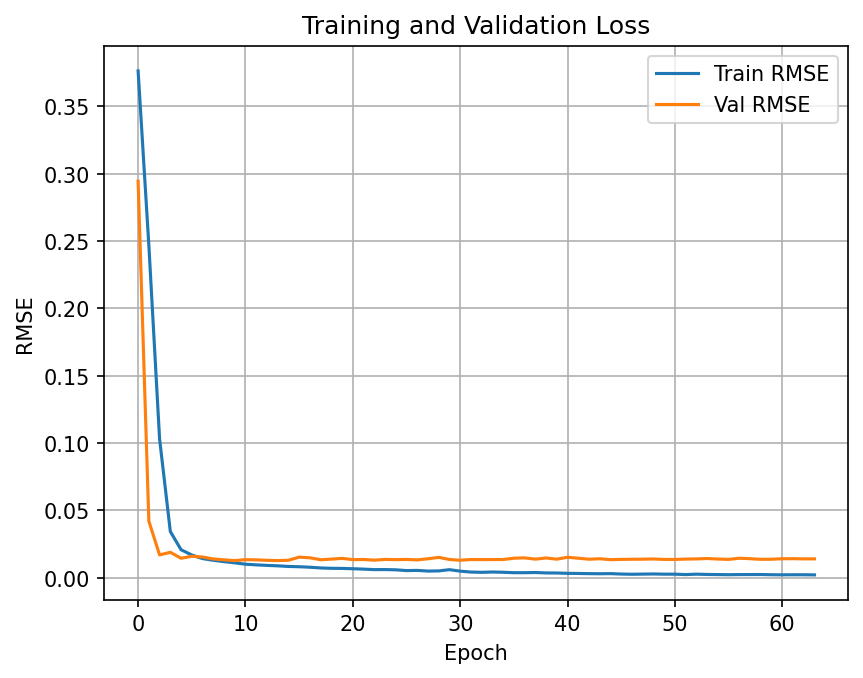

In [122]:
plot_training_loss_history(history, "RMSE")

## 2 Layer Regressor - ReLU

In [123]:
two_layer_reg = Sequential()

two_layer_reg.add(Input(shape=(X.shape[1],)))

two_layer_reg.add(Dense(512, activation="relu"))
two_layer_reg.add(Dropout(0.25))

two_layer_reg.add(Dense(512, activation="relu"))
two_layer_reg.add(Dropout(0.25))

two_layer_reg.add(Dense(1, activation="relu"))

two_layer_reg.compile(optimizer="adam", loss="mse", metrics=[rmse, r_squared])

two_layer_reg.summary()

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_47 (Dense)            (None, 512)               70144     
                                                                 
 dropout_26 (Dropout)        (None, 512)               0         
                                                                 
 dense_48 (Dense)            (None, 512)               262656    
                                                                 
 dropout_27 (Dropout)        (None, 512)               0         
                                                                 
 dense_49 (Dense)            (None, 1)                 513       
                                                                 
Total params: 333313 (1.27 MB)
Trainable params: 333313 (1.27 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [124]:
history_two_layer = nn_pipeline(two_layer_reg, X, y)

Epoch 1/1000
250/250 - 1s - loss: 0.4919 - rmse: 0.7007 - r_squared: -4.8417e+01 - val_loss: 0.4918 - val_rmse: 0.7001 - val_r_squared: -4.8414e+01 - 1s/epoch - 5ms/step
Epoch 2/1000
250/250 - 1s - loss: 0.4914 - rmse: 0.7002 - r_squared: -5.1798e+01 - val_loss: 0.4918 - val_rmse: 0.7001 - val_r_squared: -4.8414e+01 - 531ms/epoch - 2ms/step
Epoch 3/1000
250/250 - 1s - loss: 0.4914 - rmse: 0.7003 - r_squared: -5.2937e+01 - val_loss: 0.4918 - val_rmse: 0.7001 - val_r_squared: -4.8414e+01 - 542ms/epoch - 2ms/step
Epoch 4/1000
250/250 - 1s - loss: 0.4914 - rmse: 0.7003 - r_squared: -5.0046e+01 - val_loss: 0.4918 - val_rmse: 0.7001 - val_r_squared: -4.8414e+01 - 565ms/epoch - 2ms/step
Epoch 5/1000
250/250 - 1s - loss: 0.4914 - rmse: 0.7002 - r_squared: -5.0999e+01 - val_loss: 0.4918 - val_rmse: 0.7001 - val_r_squared: -4.8414e+01 - 541ms/epoch - 2ms/step
Epoch 6/1000
250/250 - 1s - loss: 0.4914 - rmse: 0.7003 - r_squared: -4.9697e+01 - val_loss: 0.4918 - val_rmse: 0.7001 - val_r_squared: -4

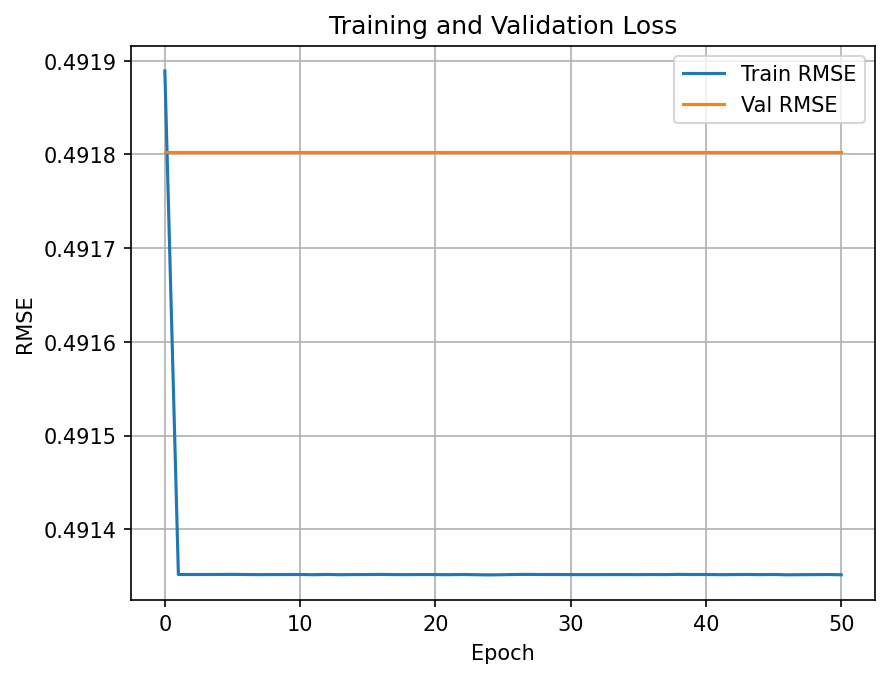

In [125]:
plot_training_loss_history(history_two_layer, "RMSE")

## Simpler Model - 1 Layer, 64 units

In [162]:
simple_layer_reg = Sequential()
simple_layer_reg.add(Input(shape=(X.shape[1],)))
simple_layer_reg.add(Dropout(0.20))
# simple_layer_reg.add(Dense(2, activation="relu"))
simple_layer_reg.add(Dense(1, activation="relu"))
simple_layer_reg.compile(optimizer="adam", loss="mse", metrics=[rmse, r_squared])
simple_layer_reg.summary()

Model: "sequential_26"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout_31 (Dropout)        (None, 136)               0         
                                                                 
 dense_54 (Dense)            (None, 1)                 137       
                                                                 
Total params: 137 (548.00 Byte)
Trainable params: 137 (548.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [163]:
history_simpler = nn_pipeline(simple_layer_reg, X, y)

Epoch 1/1000
250/250 - 1s - loss: 0.3714 - rmse: 0.5967 - r_squared: -3.6144e+01 - val_loss: 0.1280 - val_rmse: 0.3519 - val_r_squared: -1.1510e+01 - 890ms/epoch - 4ms/step
Epoch 2/1000
250/250 - 0s - loss: 0.0774 - rmse: 0.2683 - r_squared: -6.9620e+00 - val_loss: 0.0276 - val_rmse: 0.1626 - val_r_squared: -1.5042e+00 - 250ms/epoch - 1ms/step
Epoch 3/1000
250/250 - 0s - loss: 0.0277 - rmse: 0.1626 - r_squared: -1.8700e+00 - val_loss: 0.0156 - val_rmse: 0.1216 - val_r_squared: -3.2033e-01 - 245ms/epoch - 980us/step
Epoch 4/1000
250/250 - 0s - loss: 0.0176 - rmse: 0.1294 - r_squared: -6.2594e-01 - val_loss: 0.0126 - val_rmse: 0.1101 - val_r_squared: -6.2860e-02 - 243ms/epoch - 974us/step
Epoch 5/1000
250/250 - 0s - loss: 0.0162 - rmse: 0.1242 - r_squared: -5.1282e-01 - val_loss: 0.0124 - val_rmse: 0.1084 - val_r_squared: -6.6550e-03 - 245ms/epoch - 981us/step
Epoch 6/1000
250/250 - 0s - loss: 0.0144 - rmse: 0.1169 - r_squared: -3.0664e-01 - val_loss: 0.0124 - val_rmse: 0.1081 - val_r_sq

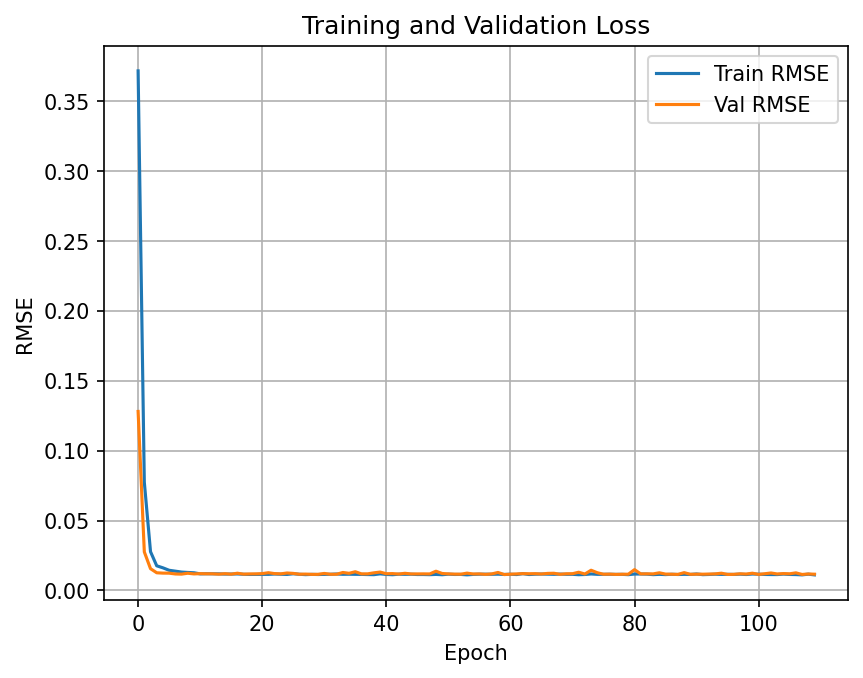

In [164]:
plot_training_loss_history(history_simpler, "RMSE")

In [165]:
X

brightness_index,square_index,total_luminosity,cooling_rate,operator_id_1,operator_id_10,operator_id_11,operator_id_12,operator_id_13,operator_id_14,operator_id_15,operator_id_16,operator_id_17,operator_id_18,operator_id_19,operator_id_2,operator_id_20,operator_id_21,operator_id_22,operator_id_23,operator_id_24,operator_id_25,operator_id_26,operator_id_27,operator_id_28,operator_id_29,operator_id_3,operator_id_30,operator_id_31,operator_id_32,operator_id_33,operator_id_34,operator_id_35,operator_id_36,operator_id_37,operator_id_38,operator_id_39,…,month_9,day_1,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_2,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_3,day_30,day_31,day_4,day_5,day_6,day_7,day_8,day_9,delta_luminosity,processing_efficiency,defect_proportion,geometry_score,brightness_times_volume
f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64
7.299983,6.381446,628.922999,18.451042,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,625.186591,0.855944,0.125826,2.947297,1449.455199
1.84512,4.592925,86.958294,9.2668,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,83.629173,1.178255,0.074265,1.395186,927.645426
3.466397,9.644985,631.647324,10.686165,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,629.885785,1.324886,0.042661,29.137112,2285.959721
6.632806,2.189785,135.185176,13.130201,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,129.11251,0.594429,0.01606,10.577933,1720.233798
4.820893,5.878564,724.827027,14.1644,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,720.060785,0.889938,0.043725,14.776397,1023.052472
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9.133047,7.758606,242.571726,27.314133,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,238.328344,0.748517,0.010677,25.882982,2562.121016
4.284731,7.507792,917.745042,24.067627,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,908.588129,0.212802,0.113988,9.403749,427.49831
3.77866,3.209786,767.732673,7.167559,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,762.753292,1.737109,0.029079,13.050104,1685.230072


In [166]:
scaler = StandardScaler()

X_train_nums = X.select(numerical_features)
X_train_nums_scaled = scaler.fit_transform(X_train_nums)
scaled_nums = pl.DataFrame(X_train_nums_scaled, schema=[f"{name}_scaled" for name in numerical_features])
X_scaled = pl.concat([X, scaled_nums], how="horizontal").drop(numerical_features)

simple_layer_reg.fit(X_scaled.to_pandas(), y.to_pandas())

125/125 [==============================] - 0s 935us/step - loss: 0.0115 - rmse: 0.1058 - r_squared: 0.1166


In [167]:
one_hot_encoded_df = test_data.to_dummies(["machine_id", "operator_id", "hour", "month", "day"])
one_hot_encoded_df

id,plate_thickness,plate_length,min_luminosity,defect_area,brightness_index,edge_index,square_index,total_luminosity,cooling_rate,processing_time,temperature,production_date,production_time,operator_id_1,operator_id_10,operator_id_11,operator_id_12,operator_id_13,operator_id_14,operator_id_15,operator_id_16,operator_id_17,operator_id_18,operator_id_19,operator_id_2,operator_id_20,operator_id_21,operator_id_22,operator_id_23,operator_id_24,operator_id_25,operator_id_26,operator_id_27,operator_id_28,operator_id_29,operator_id_3,operator_id_30,operator_id_31,operator_id_32,operator_id_33,operator_id_34,operator_id_35,operator_id_36,operator_id_37,operator_id_38,operator_id_39,operator_id_4,operator_id_40,operator_id_41,operator_id_42,operator_id_43,operator_id_44,operator_id_45,operator_id_46,operator_id_47,operator_id_48,operator_id_49,operator_id_5,operator_id_50,operator_id_6,operator_id_7,operator_id_8,operator_id_9,machine_id_M001,machine_id_M002,machine_id_M003,machine_id_M004,machine_id_M005,machine_id_M006,machine_id_M007,machine_id_M008,machine_id_M009,machine_id_M010
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8
0,6.147963,92.222021,0.731751,19.327894,6.85528,1.00516,5.334003,176.542068,31.248033,447.229755,1503.781707,"""2022-03-17""","""00:03:53""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,8.248891,57.282443,0.894784,10.232676,4.67571,0.406762,5.367562,174.433369,44.941861,490.504072,1831.769223,"""2022-05-02""","""19:54:50""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
2,7.841448,75.241924,6.519737,3.249513,0.557069,1.69761,7.597208,933.440343,39.330537,245.557092,1956.730012,"""2022-01-26""","""12:34:09""",0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,2.385099,49.244347,4.869407,3.974587,9.185102,0.939206,8.170309,140.041482,44.033253,428.860875,1677.383978,"""2022-03-10""","""07:17:16""",0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,2.343245,66.703112,7.904153,38.00236,9.803291,2.634706,3.371954,53.875627,7.674015,439.691086,1657.028551,"""2022-09-26""","""04:29:30""",0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
995,9.076576,87.189039,6.508835,43.851931,3.27487,4.761377,4.344036,766.332214,13.703825,348.97808,1760.192727,"""2022-11-22""","""13:39:24""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
996,2.074429,90.775795,1.777983,2.340698,7.269663,3.739121,4.635766,776.300589,19.375318,190.477429,1867.15353,"""2022-11-26""","""17:18:49""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
997,3.950586,95.203712,0.512395,15.184923,9.232741,0.097279,5.296669,306.09096,20.903359,399.598034,1911.263619,"""2022-02-11""","""16:17:45""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [168]:
def preprocessing_with_encoding_with_dropping_least_correlated(test: pl.DataFrame) -> pl.DataFrame:
    prods = test.with_columns(
        pl.col("production_time").str.extract(r"^(\d{2})", 1).cast(pl.Int8).alias("hour")
    )

    prods = prods.with_columns([
        pl.col("production_date").str.strptime(pl.Date, "%Y-%m-%d")
    ])

    prods = prods.with_columns([
        pl.col("production_date").dt.month().alias("month"),
        pl.col("production_date").dt.day().alias("day")
    ])

    prods = prods.drop("production_date", "production_time", "id")

    prods = prods.to_dummies(["operator_id", "hour", "month", "day"])

    test_for_eng = prods.with_columns(
        (pl.col("total_luminosity") - pl.col("min_luminosity")).alias("delta_luminosity")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("plate_thickness") * pl.col("plate_length")).alias("volume_proxy")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("volume_proxy") / pl.col("processing_time")).alias("processing_efficiency")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("defect_area") / pl.col("volume_proxy")).alias("defect_proportion")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("square_index") * pl.col("edge_index")).alias("geometry_score")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("temperature") / pl.col("cooling_rate")).alias("cooling_difficulty")
    )

    test_for_eng = test_for_eng.with_columns(
        (pl.col("brightness_index") * pl.col("volume_proxy")).alias("brightness_times_volume")
    )

    return test_for_eng.drop(
        "volume_proxy", 
        "plate_length", 
        "min_luminosity", 
        "defect_area", 
        "edge_index", 
        "processing_time", 
        "temperature",
        "cooling_difficulty",
        "plate_thickness"
    )

In [169]:
one_hot_encoded_df = preprocessing_with_encoding_with_dropping_least_correlated(one_hot_encoded_df)
one_hot_encoded_df

brightness_index,square_index,total_luminosity,cooling_rate,operator_id_1,operator_id_10,operator_id_11,operator_id_12,operator_id_13,operator_id_14,operator_id_15,operator_id_16,operator_id_17,operator_id_18,operator_id_19,operator_id_2,operator_id_20,operator_id_21,operator_id_22,operator_id_23,operator_id_24,operator_id_25,operator_id_26,operator_id_27,operator_id_28,operator_id_29,operator_id_3,operator_id_30,operator_id_31,operator_id_32,operator_id_33,operator_id_34,operator_id_35,operator_id_36,operator_id_37,operator_id_38,operator_id_39,…,month_9,day_1,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_2,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_3,day_30,day_31,day_4,day_5,day_6,day_7,day_8,day_9,delta_luminosity,processing_efficiency,defect_proportion,geometry_score,brightness_times_volume
f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,f64,f64,f64,f64,f64
6.85528,5.334003,176.542068,31.248033,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,175.810317,1.267755,0.034089,5.361525,3886.790042
4.67571,5.367562,174.433369,44.941861,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,173.538585,0.963329,0.021656,2.18332,2209.350551
0.557069,7.597208,933.440343,39.330537,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,926.920606,2.402723,0.005508,12.8971,328.673841
9.185102,8.170309,140.041482,44.033253,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,135.172075,0.273871,0.03384,7.673606,1078.814507
9.803291,3.371954,53.875627,7.674015,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,45.971474,0.355481,0.243135,8.884109,1532.271579
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
3.27487,4.344036,766.332214,13.703825,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,759.823379,2.267701,0.055412,20.683593,2591.659901
7.269663,4.635766,776.300589,19.375318,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,774.522606,0.98861,0.01243,17.333691,1368.935429
9.232741,5.296669,306.09096,20.903359,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,305.578565,0.941222,0.040374,0.515256,3472.529947


In [170]:
X_train_nums = one_hot_encoded_df.select(numerical_features)
X_train_nums_scaled = scaler.transform(X_train_nums)
scaled_nums = pl.DataFrame(X_train_nums_scaled, schema=[f"{name}_scaled" for name in numerical_features])
X_test_scaled = pl.concat([one_hot_encoded_df, scaled_nums], how="horizontal").drop(numerical_features)

y_pred_nn = simple_layer_reg.predict(X_test_scaled.to_pandas())

32/32 [==============================] - 0s 716us/step


In [175]:
y_pred_nn.reshape(len(y_pred_nn),)

array([0.717143  , 0.6661676 , 0.71017104, 0.71146494, 0.65089035,
       0.69756836, 0.7148478 , 0.6433549 , 0.717698  , 0.5773162 ,
       0.54148436, 0.70659477, 0.6692152 , 0.60902303, 0.752404  ,
       0.6788046 , 0.7342286 , 0.78459185, 0.71439785, 0.7154075 ,
       0.7035672 , 0.6424916 , 0.70402783, 0.66989493, 0.6987911 ,
       0.6397493 , 0.6719922 , 0.6629903 , 0.6944199 , 0.7394033 ,
       0.6511637 , 0.6351234 , 0.59057534, 0.6497605 , 0.63617206,
       0.7258562 , 0.5937048 , 0.6777162 , 0.7032232 , 0.6827467 ,
       0.6681675 , 0.7535032 , 0.79815036, 0.6764881 , 0.756627  ,
       0.72154003, 0.677941  , 0.6711189 , 0.6646929 , 0.7246267 ,
       0.69434667, 0.70880544, 0.6884382 , 0.6871708 , 0.6772899 ,
       0.7060256 , 0.6926653 , 0.59640664, 0.7220832 , 0.6620202 ,
       0.6606683 , 0.73701286, 0.6952443 , 0.6504933 , 0.6322153 ,
       0.78611916, 0.6947456 , 0.750929  , 0.63626456, 0.6809633 ,
       0.7833218 , 0.6418783 , 0.6437563 , 0.68796116, 0.72700

In [176]:
preds_final_nn = pl.DataFrame(
    pl.Series("quality_score", y_pred_nn.reshape(len(y_pred_nn),))
).with_row_index("id")

preds_final_nn.write_csv(SUBMISSIONS_PATH + "simpler_nn.csv")